РАСЧЁТ ЭФФЕКТИВНОСТИ ТЭС

1. ЛЕТНИЙ РЕЖИМ (неблагоприятные условия)
--------------------------------------------------
Нагрузка на блок: 200.0 МВт (67%)
КПД блока: 34.7%
КПД ТЭС брутто: 34.7%
Собственные нужды: 8.5%
КПД ТЭС нетто: 31.8%
Удельный расход топлива: 387.1 г/кВт·ч

2. ЗИМНИЙ РЕЖИМ (благоприятные условия)
--------------------------------------------------
Нагрузка на блок: 250.0 МВт (83%)
КПД блока: 41.5%
КПД ТЭС нетто: 37.6%
Удельный расход топлива: 327.2 г/кВт·ч

3. СРАВНЕНИЕ С НОМИНАЛОМ
--------------------------------------------------
Показатель                     Номинал         Факт(лето)      Отклонение     
---------------------------------------------------------------------------
КПД нетто, %                   35.7            31.8            -11.1          
Расход топлива, г/кВт·ч        344.2           387.1           +43.0          

4. ЗАВИСИМОСТЬ ОТ ТЕМПЕРАТУРЫ
--------------------------------------------------
Температура,°C | КПД нетто, % | Расход топлива, г

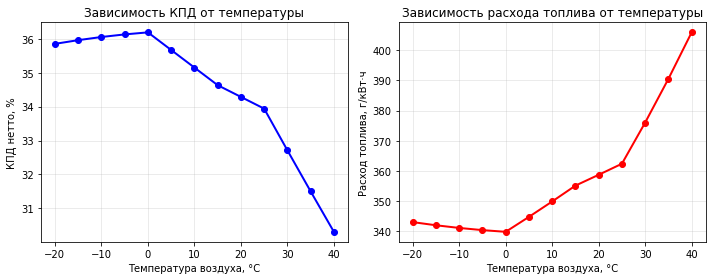


5. ОПТИМИЗАЦИЯ КОЛИЧЕСТВА БЛОКОВ
--------------------------------------------------
Блоков | Нагрузка на блок, МВт | Загрузка, % | КПД, % | Расход топлива
----------------------------------------------------------------------
     2 |               200.0 |       66.7 |   34.0 |           361.7
     3 |               133.3 |       44.4 |   31.2 |           394.3
     4 |               100.0 |       33.3 |   29.3 |           420.3


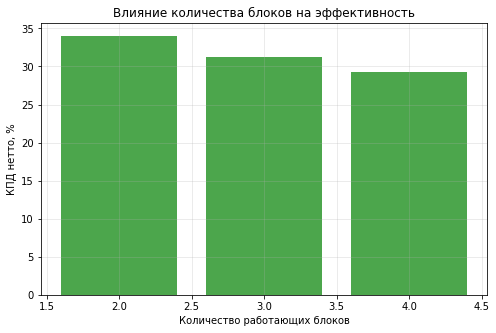


✅ Расчёты завершены!


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================================
# ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ (ПОПРАВКИ)
# ============================================================================

def temp_correction(temp_c):
    """Поправка на температуру воздуха"""
    if temp_c <= 15:
        return 1 + 0.003 * (15 - temp_c)
    else:
        return 1 - 0.002 * (temp_c - 15)

def humidity_correction(humidity):
    """Поправка на влажность"""
    if humidity <= 60:
        return 1.0
    else:
        return 1 - 0.0005 * (humidity - 60)

def wind_speed_correction(speed):
    """Поправка на скорость ветра (м/с)"""
    if speed <= 8:
        return 1 + 0.002 * speed
    else:
        return 1 + 0.002 * 8

def wind_direction_correction(direction_deg):
    """Поправка на направление ветра (градусы)"""
    angle = direction_deg % 360
    if 0 <= angle <= 45:  # ветер со стороны трубы (плохо)
        return 0.99
    elif 180 <= angle <= 225:  # встречный (хорошо)
        return 1.01
    else:
        return 1.00

def load_correction(current_power, nominal_power, base_efficiency, beta=0.4):
    """Поправка КПД на частичную нагрузку"""
    load_ratio = current_power / nominal_power
    if load_ratio >= 1:
        return base_efficiency
    return base_efficiency * (1 - beta * (1 - load_ratio) ** 2)


# ============================================================================
# ОСНОВНЫЕ РАСЧЁТНЫЕ ФУНКЦИИ
# ============================================================================

def calc_block_efficiency(power_mw, nominal_power, nominal_efficiency, 
                          temp_c, humidity, wind_speed, wind_dir, beta=0.4):
    """
    Расчёт КПД одного блока с учётом всех факторов
    
    Параметры:
    - power_mw: текущая нагрузка блока, МВт
    - nominal_power: номинальная мощность, МВт
    - nominal_efficiency: номинальный КПД (0.38 = 38%)
    - temp_c: температура воздуха, °C
    - humidity: влажность, %
    - wind_speed: скорость ветра, м/с
    - wind_dir: направление ветра, градусы
    - beta: коэффициент снижения КПД при недогрузке (0.3-0.5)
    
    Возвращает: фактический КПД блока
    """
    # Поправки на внешние условия
    k = (temp_correction(temp_c) * 
         humidity_correction(humidity) * 
         wind_speed_correction(wind_speed) * 
         wind_direction_correction(wind_dir))
    
    # КПД при номинальной нагрузке с учётом условий
    efficiency_at_nominal = nominal_efficiency * k
    
    # Поправка на текущую нагрузку
    actual_efficiency = load_correction(power_mw, nominal_power, 
                                        efficiency_at_nominal, beta)
    
    return actual_efficiency


def calc_tes_efficiency(total_load, num_blocks, nominal_power_per_block, 
                        nominal_efficiency, temp_c, humidity, 
                        wind_speed, wind_dir, own_needs_coeff=0.05, beta=0.4):
    """
    Расчёт эффективности ТЭС
    
    Параметры:
    - total_load: общая нагрузка ТЭС, МВт
    - num_blocks: количество работающих блоков
    - nominal_power_per_block: номинальная мощность одного блока, МВт
    - nominal_efficiency: номинальный КПД блока (например, 0.38)
    - temp_c, humidity, wind_speed, wind_dir: внешние условия
    - own_needs_coeff: коэффициент собственных нужд (0.05 = 5%)
    - beta: коэффициент снижения КПД
    
    Возвращает словарь с результатами
    """
    # Нагрузка на один блок (равномерное распределение)
    load_per_block = total_load / num_blocks
    
    # Проверка: не превышает ли номинальную мощность
    if load_per_block > nominal_power_per_block:
        print(f"Внимание! Блок перегружен: {load_per_block:.1f} > {nominal_power_per_block} МВт")
        load_per_block = nominal_power_per_block
    
    # КПД каждого блока (все одинаковые)
    block_efficiency = calc_block_efficiency(
        load_per_block, nominal_power_per_block, nominal_efficiency,
        temp_c, humidity, wind_speed, wind_dir, beta
    )
    
    # Суммарная мощность брутто
    total_power_brutto = num_blocks * load_per_block
    
    # КПД ТЭС брутто (совпадает с КПД блока при одинаковых блоках)
    efficiency_brutto = block_efficiency
    
    # Собственные нужды (зависят от температуры)
    own_needs = own_needs_coeff
    if temp_c > 25:
        own_needs += 0.005 * (temp_c - 25)
    elif temp_c < 0:
        own_needs += 0.003 * abs(temp_c)
    
    own_needs_power = total_power_brutto * own_needs
    total_power_netto = total_power_brutto - own_needs_power
    
    # КПД нетто
    efficiency_netto = efficiency_brutto * (1 - own_needs)
    
    # Удельный расход условного топлива (г у.т./кВт·ч)
    # 123 - тепловой эквивалент кВт·ч в ккал
    fuel_consumption = 123 / efficiency_netto if efficiency_netto > 0 else float('inf')
    
    return {
        'load_per_block': load_per_block,
        'block_efficiency': block_efficiency,
        'efficiency_brutto': efficiency_brutto,
        'efficiency_netto': efficiency_netto,
        'fuel_consumption': fuel_consumption,
        'total_power_brutto': total_power_brutto,
        'total_power_netto': total_power_netto,
        'own_needs_power': own_needs_power,
        'own_needs_percent': own_needs * 100
    }


def analyze_temperature(total_load, num_blocks, nominal_power, nominal_efficiency,
                        humidity, wind_speed, wind_dir):
    """
    Анализ зависимости КПД от температуры
    """
    temps = np.arange(-20, 41, 5)
    efficiencies = []
    fuel_rates = []
    
    for t in temps:
        res = calc_tes_efficiency(total_load, num_blocks, nominal_power, 
                                   nominal_efficiency, t, humidity, 
                                   wind_speed, wind_dir)
        efficiencies.append(res['efficiency_netto'] * 100)
        fuel_rates.append(res['fuel_consumption'])
    
    return temps, efficiencies, fuel_rates


def analyze_load_distribution(total_load, nominal_power, nominal_efficiency,
                               temp_c, humidity, wind_speed, wind_dir):
    """
    Анализ эффективности при разном количестве блоков
    """
    results = []
    for n in [1, 2, 3, 4]:
        if n * nominal_power >= total_load:
            res = calc_tes_efficiency(total_load, n, nominal_power, 
                                       nominal_efficiency, temp_c, humidity,
                                       wind_speed, wind_dir)
            results.append({
                'blocks': n,
                'load_per_block': res['load_per_block'],
                'load_percent': (res['load_per_block'] / nominal_power) * 100,
                'efficiency': res['efficiency_netto'] * 100,
                'fuel_rate': res['fuel_consumption']
            })
    return results


# ============================================================================
# ПРИМЕРЫ ИСПОЛЬЗОВАНИЯ
# ============================================================================

if __name__ == "__main__":
    
    print("=" * 70)
    print("РАСЧЁТ ЭФФЕКТИВНОСТИ ТЭС")
    print("=" * 70)
    
    # -----------------------------------------------------------
    # ПРИМЕР 1: Летний режим (жара, влажно)
    # -----------------------------------------------------------
    print("\n1. ЛЕТНИЙ РЕЖИМ (неблагоприятные условия)")
    print("-" * 50)
    
    result_summer = calc_tes_efficiency(
        total_load=400,           # МВт
        num_blocks=2,             # 2 блока
        nominal_power_per_block=300,   # МВт
        nominal_efficiency=0.38,  # 38%
        temp_c=32,                # °C
        humidity=80,              # %
        wind_speed=5,             # м/с
        wind_dir=30,              # градусы
        own_needs_coeff=0.05,
        beta=0.4
    )
    
    print(f"Нагрузка на блок: {result_summer['load_per_block']:.1f} МВт ({result_summer['load_per_block']/300*100:.0f}%)")
    print(f"КПД блока: {result_summer['block_efficiency']*100:.1f}%")
    print(f"КПД ТЭС брутто: {result_summer['efficiency_brutto']*100:.1f}%")
    print(f"Собственные нужды: {result_summer['own_needs_percent']:.1f}%")
    print(f"КПД ТЭС нетто: {result_summer['efficiency_netto']*100:.1f}%")
    print(f"Удельный расход топлива: {result_summer['fuel_consumption']:.1f} г/кВт·ч")
    
    # -----------------------------------------------------------
    # ПРИМЕР 2: Зимний режим (холодно, сухо)
    # -----------------------------------------------------------
    print("\n2. ЗИМНИЙ РЕЖИМ (благоприятные условия)")
    print("-" * 50)
    
    result_winter = calc_tes_efficiency(
        total_load=500,
        num_blocks=2,
        nominal_power_per_block=300,
        nominal_efficiency=0.38,
        temp_c=-15,
        humidity=50,
        wind_speed=2,
        wind_dir=200,     # встречный ветер
        own_needs_coeff=0.05,
        beta=0.4
    )
    
    print(f"Нагрузка на блок: {result_winter['load_per_block']:.1f} МВт ({result_winter['load_per_block']/300*100:.0f}%)")
    print(f"КПД блока: {result_winter['block_efficiency']*100:.1f}%")
    print(f"КПД ТЭС нетто: {result_winter['efficiency_netto']*100:.1f}%")
    print(f"Удельный расход топлива: {result_winter['fuel_consumption']:.1f} г/кВт·ч")
    
    # -----------------------------------------------------------
    # ПРИМЕР 3: Сравнение с номинальным режимом
    # -----------------------------------------------------------
    print("\n3. СРАВНЕНИЕ С НОМИНАЛОМ")
    print("-" * 50)
    
    result_nominal = calc_tes_efficiency(
        total_load=600,   # 2×300 МВт
        num_blocks=2,
        nominal_power_per_block=300,
        nominal_efficiency=0.38,
        temp_c=15,        # идеальная температура
        humidity=60,      # идеальная влажность
        wind_speed=0,     # штиль
        wind_dir=0
    )
    
    print(f"{'Показатель':<30} {'Номинал':<15} {'Факт(лето)':<15} {'Отклонение':<15}")
    print("-" * 75)
    print(f"{'КПД нетто, %':<30} {result_nominal['efficiency_netto']*100:<15.1f} "
          f"{result_summer['efficiency_netto']*100:<15.1f} "
          f"{result_summer['efficiency_netto']/result_nominal['efficiency_netto']*100-100:<15.1f}")
    print(f"{'Расход топлива, г/кВт·ч':<30} {result_nominal['fuel_consumption']:<15.1f} "
          f"{result_summer['fuel_consumption']:<15.1f} "
          f"+{result_summer['fuel_consumption']-result_nominal['fuel_consumption']:<14.1f}")
    
    # -----------------------------------------------------------
    # ПРИМЕР 4: Анализ зависимости от температуры
    # -----------------------------------------------------------
    print("\n4. ЗАВИСИМОСТЬ ОТ ТЕМПЕРАТУРЫ")
    print("-" * 50)
    
    temps, effs, fuels = analyze_temperature(
        total_load=400,
        num_blocks=2,
        nominal_power=300,
        nominal_efficiency=0.38,
        humidity=60,
        wind_speed=2,
        wind_dir=90
    )
    
    print("Температура,°C | КПД нетто, % | Расход топлива, г/кВт·ч")
    print("-" * 50)
    for t, eff, fuel in zip(temps, effs, fuels):
        print(f"{t:>14} | {eff:>11.1f} | {fuel:>24.1f}")
    
    # График
    plt.figure(figsize=(10, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(temps, effs, 'b-o', linewidth=2)
    plt.xlabel('Температура воздуха, °C')
    plt.ylabel('КПД нетто, %')
    plt.title('Зависимость КПД от температуры')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.plot(temps, fuels, 'r-o', linewidth=2)
    plt.xlabel('Температура воздуха, °C')
    plt.ylabel('Расход топлива, г/кВт·ч')
    plt.title('Зависимость расхода топлива от температуры')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # -----------------------------------------------------------
    # ПРИМЕР 5: Оптимальное количество блоков
    # -----------------------------------------------------------
    print("\n5. ОПТИМИЗАЦИЯ КОЛИЧЕСТВА БЛОКОВ")
    print("-" * 50)
    
    analysis = analyze_load_distribution(
        total_load=400,
        nominal_power=300,
        nominal_efficiency=0.38,
        temp_c=25,
        humidity=60,
        wind_speed=3,
        wind_dir=90
    )
    
    print("Блоков | Нагрузка на блок, МВт | Загрузка, % | КПД, % | Расход топлива")
    print("-" * 70)
    for res in analysis:
        print(f"{res['blocks']:6} | {res['load_per_block']:>19.1f} | {res['load_percent']:>10.1f} | "
              f"{res['efficiency']:>6.1f} | {res['fuel_rate']:>15.1f}")
    
    # Визуализация
    blocks_num = [r['blocks'] for r in analysis]
    effs_opt = [r['efficiency'] for r in analysis]
    
    plt.figure(figsize=(8, 5))
    plt.bar(blocks_num, effs_opt, color='green', alpha=0.7)
    plt.xlabel('Количество работающих блоков')
    plt.ylabel('КПД нетто, %')
    plt.title('Влияние количества блоков на эффективность')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    print("\n✅ Расчёты завершены!")